In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import torch.utils.data as data


torch.manual_seed(1337)
np.random.seed(1337)
random.seed(1337)

In [92]:
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

In [93]:
def preprocess_data(dataset):
    data = (dataset.data / 255.0) - 0.5
    flattened_data = data.view(data.shape[0], -1)
    targets = dataset.targets
    return flattened_data, targets

x_train_flat, y_train = preprocess_data(trainset)
x_test_flat, y_test = preprocess_data(testset)

x_train_2d=trainset.data.float() / 255.0 - 0.5
x_test_2d=testset.data.float() / 255.0 - 0.5
x_train_2d=x_train_2d.unsqueeze(1)
x_test_2d=x_test_2d.unsqueeze(1)


In [94]:
class DenseNetwork(nn.Module):
    def __init__(self,layer_sizes):
        super().__init__()
        self.layers=nn.ModuleList()
        for i in range(len(layer_sizes)-1):
            self.layers.append(nn.Linear(layer_sizes[i],layer_sizes[i+1]))
        
        self.activation=nn.Tanh()

    def forward(self, x):
        for layer in self.layers[:-1]:
            x=self.activation(layer(x))
        return self.layers[-1](x)
    def count_params(self):
        return sum(p.numel()for p in self.parameters())

In [95]:
class SimpleCNN(nn.Module):
    def __init__(self, conv_channels, kernel_size, dense_layers):
        super().__init__()
        self.conv1=nn.Conv2d(1,conv_channels,kernel_size=kernel_size,padding=kernel_size//2)
        self.activation=nn.Tanh()
        conv_output_size=28*28*conv_channels
        self.dense_layers=nn.ModuleList()
        prev_size=conv_output_size
        
        for size in dense_layers:
            self.dense_layers.append(nn.Linear(prev_size,size))
            prev_size=size
        
        self.output_layer=nn.Linear(prev_size,10)
    def forward(self, x):
        x=self.activation(self.conv1(x))
        x=x.view(x.size(0),-1)
        for layer in self.dense_layers:
            x=self.activation(layer(x))
        x=self.output_layer(x)
        return x
    def count_params(self):
        return sum(p.numel()for p in self.parameters())

In [96]:
class TwoConvCNN(nn.Module):
    def __init__(self, conv1_channels, kernel1_size, dense_layers,conv2_channels, kernel2_size):
        super().__init__()
        self.conv1=nn.Conv2d(1,conv1_channels,kernel_size=kernel1_size,padding=kernel1_size//2)
        self.conv2 = nn.Conv2d(conv1_channels, conv2_channels, kernel_size=kernel2_size, padding=kernel2_size//2)  # Fixed line

        self.activation=nn.Tanh()
        conv_output_size=28*28*conv2_channels
        self.dense_layers=nn.ModuleList()
        prev_size=conv_output_size
        
        for size in dense_layers:
            self.dense_layers.append(nn.Linear(prev_size,size))
            prev_size=size
        
        self.output_layer=nn.Linear(prev_size,10)
    def forward(self, x):
        x=self.activation(self.conv1(x))
        x=self.activation(self.conv2(x))

        x=x.view(x.size(0),-1)
        for layer in self.dense_layers:
            x=self.activation(layer(x))
        x=self.output_layer(x)
        return x
    def count_params(self):
        return sum(p.numel()for p in self.parameters())

In [ ]:
def train_model(model, x_train, y_train, x_test, y_test, epochs=10, lr=0.01, 
                weight_decay=1e-3, batch_size=1024):
    loss_function=nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_loader = data.DataLoader(data.TensorDataset(x_train, y_train), 
                              batch_size=batch_size, shuffle=True)
    train_losses=[]
    test_losses=[]
    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        for x_batch, y_batch in train_loader:
            logits = model(x_batch)
            loss = loss_function(logits, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss+=loss.item()
        
        train_loss = total_loss/len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        with torch.no_grad():
            logits = model(x_test)
            test_loss = loss_function(logits, y_test).item()
            test_losses.append(test_loss)
    return train_losses,test_losses

In [ ]:
#dense model
dense_model=DenseNetwork([784,128,10])
print(f'Parameters: {dense_model.count_params():,}')
dense_train_losses, dense_test_losses = train_model(
    dense_model, x_train_flat, y_train, x_test_flat, y_test,
    epochs=10, lr=0.01, weight_decay=1e-3
)

Parameters: 101,770


In [99]:
print(f'test loss: {dense_test_losses[-1]:.4f}')

test loss: 0.4283


In [ ]:
cnn_configs = [
    # (conv_channels, kernel_size, dense_layers, name)
    (4, 3, [], "4ch-3x3-nodense"),
    (8, 3, [], "8ch-3x3-nodense"),
    (4, 5, [], "4ch-5x5-nodense"),
    (8, 5, [], "8ch-5x5-nodense"),
    (16, 3, [], "16ch-3x3-nodense"),
    (4, 3, [32], "4ch-3x3-dense32"),
    (8, 3, [32], "8ch-3x3-dense32"),
    (4, 5, [32], "4ch-5x5-dense32"),
]

ans_cnn=None
best_test_loss=float('inf')
best_config=None
cnn_results=[]

for conv_ch, kernel, dense, name in cnn_configs:
    print(f"\Trying: {name}")
    cnn=SimpleCNN(conv_ch, kernel, dense)
    params=cnn.count_params()
    print(f"\Parameters: {params:,}")
    
    if params > dense_model.count_params():
        print(f"skipped")
        continue
    
    train_losses, test_losses = train_model(cnn, x_train_2d, y_train, x_test_2d, y_test,epochs=10, lr=0.01, weight_decay=1e-3, batch_size=1024
)
    
    test_loss=test_losses[-1]
    print(f"\test loss: {test_loss:.4f}")
    
    cnn_results.append({
        'name': name,
        'params': params,
        'test_loss': test_loss,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'config': (conv_ch, kernel, dense)
    })
    
    if test_loss <= dense_test_losses[-1] and params < ans_cnn.count_params() if ans_cnn else True:
        ans_cnn = cnn
        best_test_loss = test_loss
        best_config = (conv_ch, kernel, dense, name)

if ans_cnn:
    print('result: ')
    print(f"config: {best_config[3]}")
    print(f"parameters: {ans_cnn.count_params():,} dense: {dense_model.count_params():,}")
    print(f"test loss: {best_test_loss:.4f} dense:  {dense_test_losses[-1]:.4f}")
else:
    print("no optimal")


\Trying: 4ch-3x3-nodense
\Parameters: 31,410
	est loss: 0.3060
result: 
config: 4ch-3x3-nodense
parameters: 31,410 dense: 101,770
test loss: 0.3060 dense:  0.4283


When debugging for later part, it's too troubling to run the code again. At such time, the result already determined is run. Below are whole outputs: 
\Trying: 4ch-3x3-nodense
\Parameters: 31,410
    est loss: 0.3060
\Trying: 8ch-3x3-nodense
\Parameters: 62,810
    est loss: 0.2976
\Trying: 4ch-5x5-nodense
\Parameters: 31,474
    est loss: 0.2979
\Trying: 8ch-5x5-nodense
\Parameters: 62,938
    est loss: 0.2958
\Trying: 16ch-3x3-nodense
\Parameters: 125,610
skipped
\Trying: 4ch-3x3-dense32
\Parameters: 100,754
    est loss: 0.3353
\Trying: 8ch-3x3-dense32
\Parameters: 201,146
skipped
\Trying: 4ch-5x5-dense32
\Parameters: 100,818
    est loss: 0.3330
result: 
config: 4ch-3x3-nodense
parameters: 31,410 dense: 101,770
test loss: 0.3060 dense:  0.4283

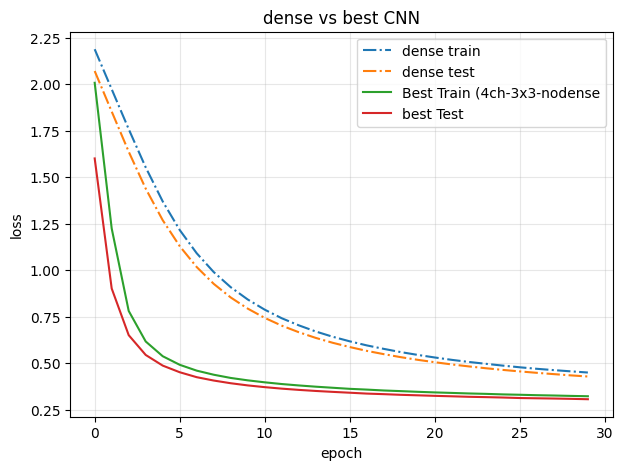

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(dense_train_losses,label='dense train',linestyle='-.')
plt.plot(dense_test_losses,label='dense test',linestyle='-.')
best_result=[x for x in cnn_results if x['name']==best_config[3]][0]
plt.plot(best_result['train_losses'],label=f'Best Train ({best_config[3]}')
plt.plot(best_result['test_losses'],label=f'best Test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('dense vs best CNN')
plt.legend()
plt.grid(alpha=.3)



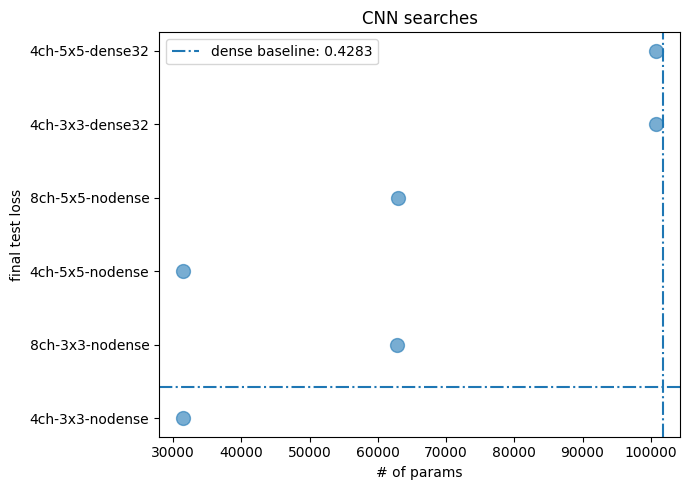

In [ ]:
plt.figure(figsize=(7,5))
params_list=[x['params']for x in cnn_results]
names_list=[x['name'] for x in cnn_results]
test_losses_list=[x['test_loss'] for x in cnn_results]

plt.scatter(params_list, names_list, s=100, alpha=0.6)

plt.axhline(y=dense_test_losses[-1],linestyle='-.',label=f'dense baseline: {dense_test_losses[-1]:.4f}')
plt.axvline(x=dense_model.count_params(), linestyle='-.')

plt.xlabel('# of params')
plt.ylabel('final test loss')
plt.title('CNN searches')
plt.legend()

plt.tight_layout()
plt.show()

The best CNN, 4ch 3x3 nodense with 31410 parameters, consistently performs better than dense baseline. Additionally, it also decreases faster. That is, a single convolutional layer is more efficient. 

In [103]:
# 2 conv layers

single_conv_loss=best_test_loss
single_conv_params=ans_cnn.count_params()

two_conv_configs = [
        # (conv1_ch, kernel1, conv2_ch, kernel2, dense_layers, name)
        (2, 3, 2, 3, [], "2ch-3x3_2ch-3x3"),
        (3, 3, 2, 3, [], "3ch-3x3_2ch-3x3"),
        (2, 3, 3, 3, [], "2ch-3x3_3ch-3x3"),
        (3, 3, 3, 3, [], "3ch-3x3_3ch-3x3"),
        (4, 3, 2, 3, [], "4ch-3x3_2ch-3x3"),
        (2, 3, 4, 3, [], "2ch-3x3_4ch-3x3"),
        (4, 3, 3, 3, [], "4ch-3x3_3ch-3x3"),
        (3, 3, 4, 3, [], "3ch-3x3_4ch-3x3"),
        (2, 5, 2, 3, [], "2ch-5x5_2ch-3x3"),
        (2, 3, 2, 5, [], "2ch-3x3_2ch-5x5"),
        (3, 5, 3, 3, [], "3ch-5x5_3ch-3x3"),
        (3, 3, 3, 5, [], "3ch-3x3_3ch-5x5"),
    ]
two_conv_results=[]

for conv1_ch, k1, conv2_ch, k2, dense, name in two_conv_configs:
        print(f"\nTrying: {name}")
        cnn2 = TwoConvCNN(conv1_ch, k1, dense, conv2_ch, k2)
        params = cnn2.count_params()
        print(f"parameters: {params:,}")

        #skip when more params needed
        if params > single_conv_params:
            print(f"skipped")
            continue
        
        train_losses, test_losses = train_model(
            cnn2, x_train_2d, y_train, x_test_2d, y_test,
            epochs=10, lr=0.01, weight_decay=1e-3, batch_size=1024
        )
        
        final_test_loss=test_losses[-1]
        print(f'Final test loss: {final_test_loss:.4f}')
        
        improvement=single_conv_loss-final_test_loss
        print(f"improvement: {improvement:.4f}")
        
        two_conv_results.append({
            'name': name,
            'params': params,
            'test_loss': final_test_loss,
            'train_losses': train_losses,
            'test_losses': test_losses,
            'improvement': improvement
        })

best_2_conv=max(two_conv_results,key=lambda x: x['improvement'])



Trying: 2ch-3x3_2ch-3x3
parameters: 15,748
Final test loss: 0.3665
improvement: -0.0605

Trying: 3ch-3x3_2ch-3x3
parameters: 15,776


KeyboardInterrupt: 

In [ ]:

print('Result: ')
print(f'config: {best_2_conv['name']}')
print(f'2 conv params: {best_2_conv['params']} | 1 conv params: {single_conv_params:,}')
print(f'Improvement: {best_2_conv['Improvement']:.4f}')
print(f'2 conv test Loss: {best_2_conv['test_loss']:.4f} | 1 conv params: {single_conv_loss:.4f}')






Previously, under the same setting as 1 layer, 2 layer CNN didn't outperform. It was: 
Trying: 4ch-3x3_4ch-3x3
parameters: 31,558
skipped
Trying: 4ch-3x3_8ch-3x3
parameters: 63,066
skipped
Trying: 8ch-3x3_4ch-3x3
parameters: 31,742
skipped
Trying: 8ch-3x3_8ch-3x3
parameters: 63,394
skipped
Trying: 4ch-5x5_4ch-3x3
parameters: 31,622
skipped
Trying: 4ch-3x3_4ch-5x5
parameters: 31,814
skipped

With all two-conv config having more parameters, they are being skipped, as violating the “smallest model that matches or exceeds” criterion. It theoretically could improve test loss, but per parameter performance seems worse.